In [1]:
import numpy as np
import pandas as pd 

In [2]:
dataset = pd.read_csv("sh.csv")

In [3]:
dataset

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar… then Joking wif u oni…
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [5]:
dataset.describe()

,v1,v2
count,5572,5572
unique,2,5171
top,ham,"Sorry, I'll call later"
freq,4825,30


In [6]:
dataset.isnull()

,v1,v2
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
5567,False,False
5568,False,False
5569,False,False
5570,False,False


In [7]:
dataset.rename(columns={'v1':'classes', 'v2':'msg'},inplace=True)



In [8]:
dataset

,classes,msg
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar… then Joking wif u oni…
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [9]:
dataset['labels'] = dataset['classes'].map({'ham':0,
                                           'spam':1})
dataset

,classes,msg,labels
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar… then Joking wif u oni…,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will Ì_ b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

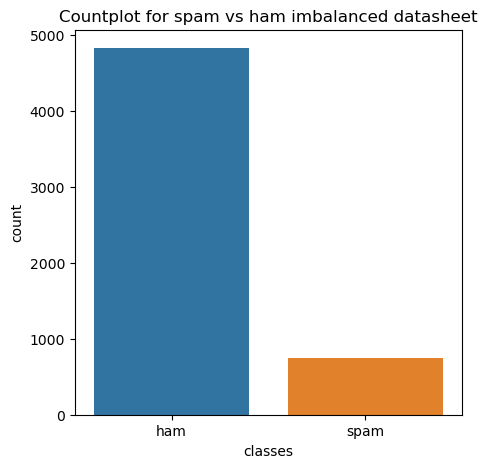

In [11]:
#countplot for spam vs ham imbalanced datasheet
plt.figure(figsize=(5,5))
g = sns.countplot(x = 'classes', data = dataset)
plt.title("Countplot for spam vs ham imbalanced datasheet")
plt.show()

#### Now we have to handle this imbalanced datasheet and convert it into balanced datsheet

In [12]:
only_spam = dataset[dataset['labels'] == 1]
only_spam

,classes,msg,labels
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1
8,spam,WINNER!! As a valued network customer you have...,1
9,spam,Had your mobile 11 months or more? U R entitle...,1
11,spam,"SIX chances to win CASH! From 100 to 20,000 po...",1
...,...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...,1
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...,1
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...,1


In [13]:
print(len(only_spam))

print(len(dataset)-len(only_spam))

747
4825


In [14]:
count = int((len(dataset)-len(only_spam))/len(only_spam))
count

6

In [15]:
for i in range (0, count-1):
    dataset = pd.concat([dataset, only_spam])
dataset.shape

(9307, 3)

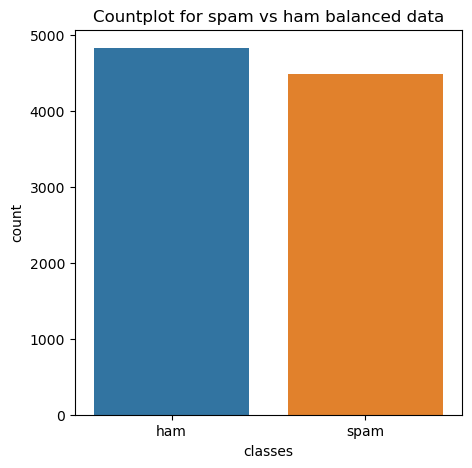

In [16]:
#countplot for spam vs ham balanced sheet
plt.figure(figsize=(5,5))
g = sns.countplot(x = 'classes', data = dataset)
plt.title('Countplot for spam vs ham balanced data')
plt.show()

In [17]:
dataset['word_count'] = dataset['msg'].apply(lambda x: len(x.split()))
dataset

,classes,msg,labels,word_count
0,ham,"Go until jurong point, crazy.. Available only ...",0,20
1,ham,Ok lar… then Joking wif u oni…,0,7
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,28
3,ham,U dun say so early hor... U c already then say...,0,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,13
...,...,...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...,1,16
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,33
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...,1,28
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...,1,28


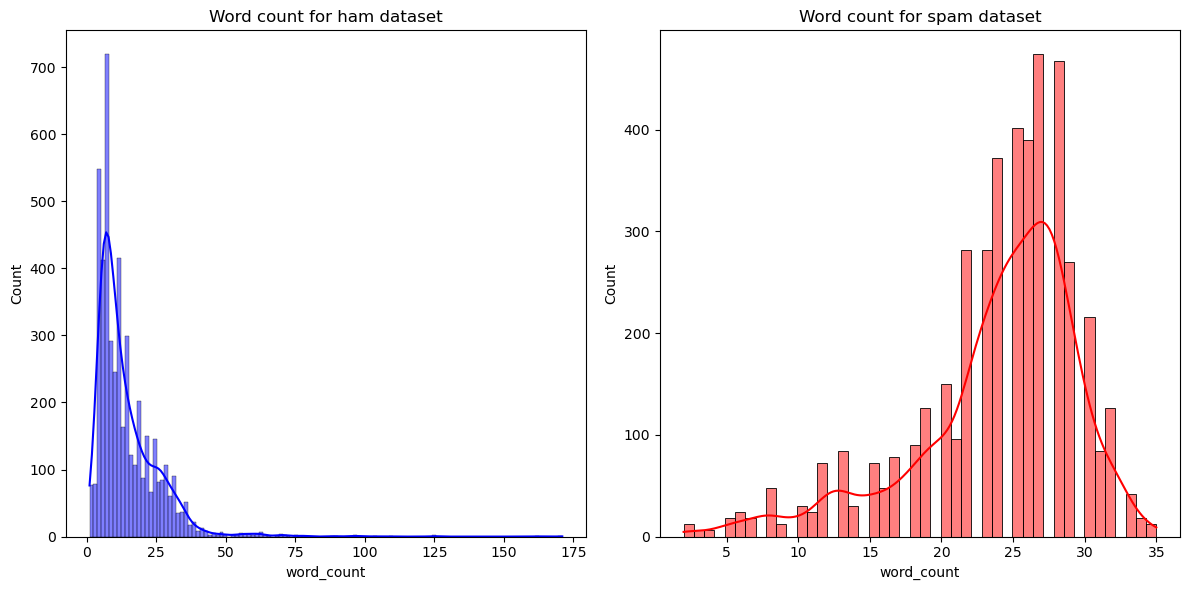

In [18]:
plt.figure(figsize=(12,6))

#1st plot
plt.subplot(1,2,1)
g = sns.histplot(dataset[dataset['labels'] == 0].word_count, kde=True,color='blue')
plt.title('Word count for ham dataset')

#2nd plot
plt.subplot(1,2,2)
g = sns.histplot(dataset[dataset['labels'] == 1].word_count, kde=True,color='red')
plt.title('Word count for spam dataset')

plt.tight_layout()
plt.show()

In [19]:
#creating new funtion for containing currency symbols
currency_sign = ['₹', '$', '€', '£', '¥']
def currency_present(txt):
  for i in currency_sign:
     if i in txt:
         return 1
  return 0

In [20]:
dataset['contains_currency_symbols'] = dataset['msg'].apply(currency_present)
dataset

,classes,msg,labels,word_count,contains_currency_symbols
0,ham,"Go until jurong point, crazy.. Available only ...",0,20,0
1,ham,Ok lar… then Joking wif u oni…,0,7,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,28,0
3,ham,U dun say so early hor... U c already then say...,0,11,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,13,0
...,...,...,...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...,1,16,0
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,33,1
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...,1,28,0
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...,1,28,0


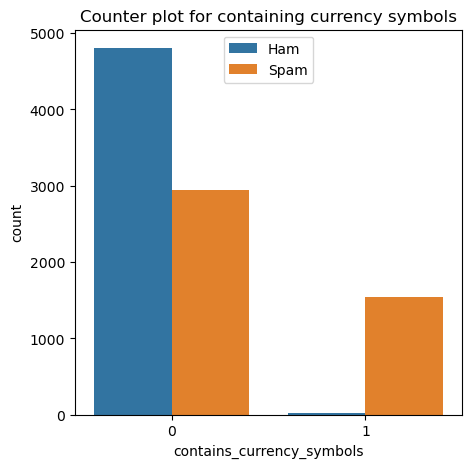

In [21]:
plt.figure(figsize=(5,5))
g = sns.countplot(x = 'contains_currency_symbols', data=dataset, hue='labels')
plt.title("Counter plot for containing currency symbols")
plt.legend(labels=['Ham','Spam'], loc=9)

In [22]:
#creating new feature of containing nos.
def number(txt):
    for i in txt:
        if i>='0' and i<='9':
#         if ord(i) >= 48 and ord(i) <= 57:
            return 'yes'
    return 'no' 

In [23]:
dataset['contain_nos'] = dataset['msg'].apply(number)

In [24]:
dataset

,classes,msg,labels,word_count,contains_currency_symbols,contain_nos
0,ham,"Go until jurong point, crazy.. Available only ...",0,20,0,no
1,ham,Ok lar… then Joking wif u oni…,0,7,0,no
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,28,0,yes
3,ham,U dun say so early hor... U c already then say...,0,11,0,no
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,13,0,no
...,...,...,...,...,...,...
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...,1,16,0,yes
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,1,33,1,yes
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...,1,28,0,yes
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...,1,28,0,yes


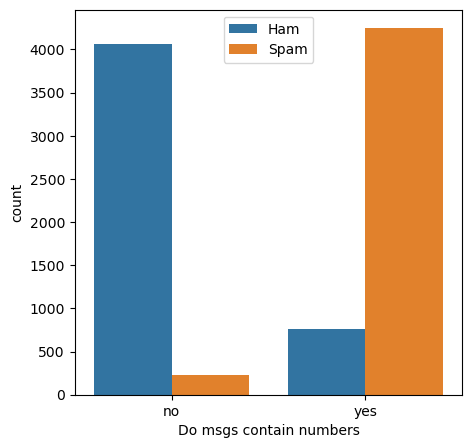

In [25]:
#countplot of balanced spam vs ham datasheet of msgs containing nos
plt.figure(figsize=(5,5))
g = sns.countplot(x = 'contain_nos', data=dataset, hue='labels')
plt.xlabel("Do msgs contain numbers")
plt.legend(labels=['Ham','Spam'])

In [26]:
import nltk
import re
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\riyag\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\riyag\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
corpus = []
wnl = WordNetLemmatizer()

# for sms in list(dataset.msg):
#     msg= re.sub(pattern='[a-zA-Z]', repl=' ',string=sms)
#     msg=msg.lower()
#     words = msg.split()
#     filtered_words = [word for word in words if word not in set(stopwords.words('english'))]
#     lem_words = [wnl.lemmatize(word) for word in filtered_words]
#     msg = ' '.join(lem_words)
#     corpus.append(msg)
for sms in list(dataset.msg):
    cleaned_msg = re.sub(pattern='[^a-zA-Z0-9]', repl=' ', string=sms)
    cleaned_msg = cleaned_msg.lower()
    words = cleaned_msg.split()
    filtered_words = [word for word in words if word not in set(stopwords.words('english'))]
    lem_words = [wnl.lemmatize(word) for word in filtered_words]
    cleaned_msg = ' '.join(lem_words)
    corpus.append(cleaned_msg)

In [28]:
corpus

['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry question std txt rate c apply 08452810075over18',
 'u dun say early hor u c already say',
 'nah think go usf life around though',
 'freemsg hey darling 3 week word back like fun still tb ok xxx std chgs send 1 50 rcv',
 'even brother like speak treat like aid patent',
 'per request melle melle oru minnaminunginte nurungu vettam set callertune caller press 9 copy friend callertune',
 'winner valued network customer selected receivea 900 prize reward claim call 09061701461 claim code kl341 valid 12 hour',
 'mobile 11 month u r entitled update latest colour mobile camera free call mobile update co free 08002986030',
 'gonna home soon want talk stuff anymore tonight k cried enough today',
 'six chance win cash 100 20 000 pound txt csh11 send 87575 cost 150p day 6days 16 tsandcs apply reply

In [29]:
#creating a bag of words model
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=500)
vectors = tfidf.fit_transform(corpus).toarray()
feature_names = tfidf.get_feature_names_out()

In [30]:
X = pd.DataFrame(vectors, columns = feature_names)
y = dataset['labels']

In [31]:
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [32]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
X_train

,00,000,02,03,04,06,0800,08000839402,08000930705,0870,...,xmas,xxx,ya,yeah,year,yes,yet,yo,yr,yup
3533,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4253,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.281544,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7191,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5191,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5390,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
860,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
#Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB
mnb = MultinomialNB()
cv = cross_val_score(mnb, X, y, scoring='f1', cv=10)
print(round(cv.mean(),3))
print(round(cv.std(),3))

0.947
0.004


In [35]:
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)

In [36]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       958
           1       0.94      0.95      0.95       904

    accuracy                           0.95      1862
   macro avg       0.95      0.95      0.95      1862
weighted avg       0.95      0.95      0.95      1862



In [37]:
cm = confusion_matrix(y_test,y_pred)
cm 

array([[908,  50],
       [ 49, 855]], dtype=int64)

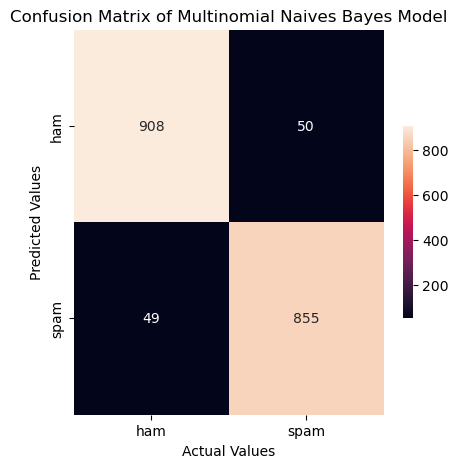

In [38]:
plt.figure(figsize=(5,5))
axis_labels = ['ham','spam']
g = sns.heatmap(data=cm, xticklabels=axis_labels,yticklabels=axis_labels, annot=True, fmt='g', cbar_kws= {'shrink':0.5})
plt.title('Confusion Matrix of Multinomial Naives Bayes Model')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In [39]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
cv1 = cross_val_score(dt, X, y, scoring='f1', cv=10)
print(round(cv1.mean(),3))
print(round(cv1.std(),3))

0.98
0.003


In [40]:
dt.fit(X_train, y_train)
y_pred1 = dt.predict(X_test)

In [41]:
print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       958
           1       0.96      1.00      0.98       904

    accuracy                           0.98      1862
   macro avg       0.98      0.98      0.98      1862
weighted avg       0.98      0.98      0.98      1862



In [42]:
cm = confusion_matrix(y_test, y_pred1)
cm

array([[917,  41],
       [  3, 901]], dtype=int64)

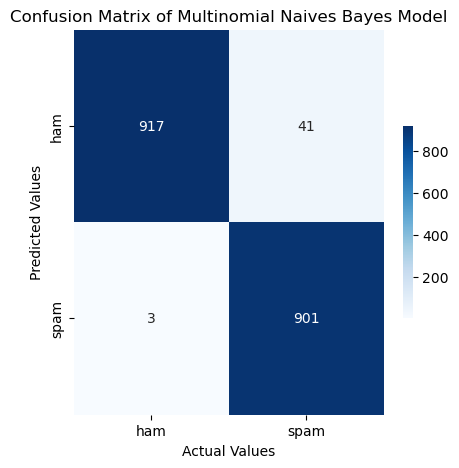

In [43]:
plt.figure(figsize=(5,5))
axis_labels = ['ham','spam']
g = sns.heatmap(data=cm, xticklabels=axis_labels,yticklabels=axis_labels, annot=True, fmt='g', cbar_kws= {'shrink':0.5}, cmap="Blues")
plt.title('Confusion Matrix of Multinomial Naives Bayes Model')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In [44]:
def predict_spam(sms):
    cleaned_msg = re.sub(pattern='[^a-zA-Z0-9]', repl=' ', string=sms)
    cleaned_msg = cleaned_msg.lower()
    words = cleaned_msg.split()
    filtered_words = [word for word in words if word not in set(stopwords.words('english'))]
    lem_words = [wnl.lemmatize(word) for word in filtered_words]
    cleaned_msg = ' '.join(lem_words)
    temp = tfidf.transform([cleaned_msg]).toarray()
    return dt.predict(temp)

In [46]:
#Prediction 1
sample_msg = "Want to win $5,000 in this summer’s treasure hunt? Text “YES” to 4555 to reserve your ticket.T&Cs apply. "
if predict_spam(sample_msg):
    print("It's a spam.")
else:
    print("It's a normal message.")

It's a spam.


C:\Users\riyag\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
